In [5]:
# Churn Analysis - Churn occur when a customer stop doing bussines with company .

In [1]:
# import liberaries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import sqlite3
import datetime as dt

In [ ]:
#1. import database / data
conn = sqlite3.connect('customer_churn.db')

sql_query = """
        SELECT name 
        FROM sqlite_master
        WHERE type = 'table'
        """

tables = pd.read_sql(sql_query,conn)

# create database for each table
for tb_name in tables['name']:
    # step1 : get the data .
    df = pd.read_sql(f"SELECT * FROM {tb_name}",conn)
    # step2 : put a label on it .
    globals()[f"df_{tb_name}"] = df
    
    print(f"Created dataframe : df_{tb_name}")


Created dataframe : df_db_customer
Created dataframe : df_db_subscription
Created dataframe : df_db_support


In [ ]:
# print table names and column names 
conn = sqlite3.connect('customer_churn.db')

for table_name in tables ['name']:
    print(f"\nTable Name : {table_name}")
    # get column info
    col_query = f"PRAGMA table_info({table_name});"
    cols = pd.read_sql(col_query, conn)
    print(cols['name'].tolist())

# close connection
conn.close()


Table Name : db_customer
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name : db_subscription
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name : db_support
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [ ]:
 # Data Cleaning

In [ ]:
df_db_customer.head()
# df_db_customer.tail() 


,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [ ]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [ ]:
# a. rename col - name to customer_name
# b. drop columns - interest and pincode
# c. change datatype - dob (object to datetime)
# d. fix missing values - country 
# e. data standardization - gender ( male, female)

In [ ]:
# a. rename col - name to customer_name
# shift + tab to see the attribute of func
df_db_customer.rename(columns= {'name' : 'customer_name'},inplace= True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [ ]:
# b. drop columns - interest and pincode
# axis 1 for col and 0 for row 
# df_db_customer.drop(df_db_customer.columns[-2], axis=1)

df_db_customer.drop(columns= ['interests','pincode'], inplace = True)

In [ ]:
# c. change datatype - dob (object to datetime)
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [ ]:
# d. fix missing values - country 
#  this will return only those row which have null values
# df_db_customer[df_db_customer['country'].isna()]

# simple fill it with temp data. (Not an optimal methord)
# df_db_customer['country'].fillna('Nahi Pata')

# country and state - unique value pair (limitation but if india and america have some common state)
state_country_mapping = df_db_customer.dropna(subset=['country']) .set_index('state')['country'].to_dict()

df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

0     India
1     India
2     India
3     India
4     India
5     India
6     India
7     India
8     Nepal
9     Nepal
10    India
11    India
12    India
13    India
14    India
15    India
16    India
17    India
18    India
19    India
20    India
Name: country, dtype: object

In [ ]:
# e. data standardization - gender ( male, female)
df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'},inplace= True)
 

In [ ]:
df_db_customer['gender'].unique()

array(['Male', 'Female', nan], dtype=object)

In [ ]:
# ----------- Next Table - df_db_subscription----------------

In [ ]:
df_db_subscription.info( )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [ ]:
# change datatype of subscription_start_date and cancellation_date
df_db_subscription['subscription_start_date'] = pd.to_datetime(df_db_subscription['subscription_start_date'])
df_db_subscription['cancellation_date'] = pd.to_datetime(df_db_subscription['cancellation_date'])

In [ ]:
# convert object to datetime format

date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col].apply(pd.to_datetime)

,subscription_start_date,renewal_date,cancellation_date
0,2021-03-15,2025-03-15,NaT
1,2020-08-01,2024-08-01,2024-09-10
2,2022-11-20,2025-11-20,NaT
3,2019-05-10,2025-05-10,NaT
4,2023-01-05,2024-01-05,2024-02-28
5,2022-06-18,2025-06-18,NaT
6,2021-09-30,2024-09-30,2024-11-15
7,2020-02-14,2025-02-14,NaT
8,2023-07-22,2024-07-22,NaT
9,2022-04-03,2025-04-03,NaT


In [ ]:
# ----------------Next table - support----------------
# df_db_support.info()
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [ ]:
# remove comment and col_1 columns
df_db_support.drop(columns=['comment','col_1'], inplace= True)

In [ ]:
# change datatype of complaint_date
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [ ]:
# 3. FEATURE ENGINEERING AND DATA ANALYSIS

In [ ]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1,0)

In [ ]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [ ]:
# Merging tables and storing in df


In [ ]:
# through shape we can find number of rows and column in my table
df_db_subscription.shape

(21, 12)

In [ ]:
df.shape

(9, 4)

In [ ]:
# how to find duplicate data in my table
# .unique() will return unique customer ids 
# but .nunique() will return no of unique customers
df_db_subscription['customerid'].nunique()

21

In [ ]:
# same we will check for customer and support table
df_db_customer['customerid'].nunique()

21

In [ ]:
df_db_support['customerid'].nunique()

7

In [ ]:
# checking the size of table
df_db_support['customerid'].size
#  from here we get to know support was adding extra two rows when left joined 

9

In [ ]:
# lets fix it - we will consider only the last review by the customer 
#  make a new column name complain_count 
df_db_support['complaint_count']= df_db_support.groupby('customerid')['customerid'].transform('count')

In [ ]:
# this will sort the support table with respect to complaint_date and remove duplicates. 
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')

In [ ]:
# first fix support table duplicate then merge
df = (df_db_subscription.merge(df_db_customer, on = 'customerid',how='left')
                   .merge(df_db_support, on = 'customerid',how='left'))
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,...,0,durga,None,Delhi,Women,1988-12-10,2025-03-18,N,90.0,1.0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0,1.0
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,...,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN,NaN
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,...,0,maya,None,Kathmandu,Women,1985-07-07,NaT,NaN,NaN,NaN
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,...,0,arjun,Nepal,Kathmandu,Male,1993-10-29,NaT,NaN,NaN,NaN


In [ ]:
df.shape

(21, 21)

In [ ]:
# convert this table to an csv file( excel format)
df.to_csv('export_churn_data.csv',index= False)

In [ ]:
#  4. Data Analysis

In [ ]:
# 1. Churn rate
#  to check all the columns name
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [ ]:
# df['churn_flag'].mean()
churn_rate = df['churn_flag'].mean() * 100
print(f"Churn Rate = {round(churn_rate,2)} %")

Churn Rate = 28.57 %


In [ ]:
# 2. Retention Rate (opposite of churn rate)
Retention_rate = 100 - churn_rate
print(f'Retention Rate = {round(Retention_rate,2)} %')

Retention Rate = 71.43 %


In [ ]:
# 3. churn by plan type (which customers are we loosing most)
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean() .mul(100).round(2).reset_index(name = 'churn_by_pct'))
print(churn_by_plan)

  plan_type  churn_by_pct
0     Basic         60.00
1   Premium         14.29
2  Standard         22.22


In [ ]:
# 4a. Churn by state + sum(revenue) & count of users -- home work**
# churn_by_state = (df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name= 'churn_by_st'))

churn_by_state = (df.groupby('state')['churn_flag']).agg(['sum','count','mean']).reset_index()
churn_by_state.columns = ['State','Sum','Count','Churn_rate']
churn_by_state['Churn_rate'] = (churn_by_state['Churn_rate'] * 100).round(2)
print(churn_by_state)
# .reset_index(name= 'churn_by_st') -> this will give name and will reste the index to 0,1,2

           State  Sum  Count  Churn_rate
0          Delhi    1      4       25.00
1      Karnataka    2      2      100.00
2      Kathmandu    0      2        0.00
3    Maharashtra    0      3        0.00
4      Meghalaya    2      3       66.67
5       Nagaland    0      1        0.00
6      Rajasthan    0      2        0.00
7      Telangana    1      2       50.00
8  Uttar Pradesh    0      2        0.00


In [ ]:
# 4b. Churn by subscription type -- home work**
churn_by_subscription = (df.groupby('subscription_type')['churn_flag']).agg(['sum','count','mean']).reset_index()
churn_by_subscription.columns = ['Subscription_type','Sum','Count','Churn_rate']
churn_by_subscription['Churn_rate'] = (churn_by_subscription['Churn_rate'] * 100) .round(2)
print(churn_by_subscription)

  Subscription_type  Sum  Count  Churn_rate
0           Organic    0      9        0.00
1              Paid    1      6       16.67
2          Refferal    5      6       83.33


In [ ]:
# 5. ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean().round(2)
print(f'ARPU = {arpu}') 

ARPU = 18.85


In [ ]:
# 6. Avg customer Tenure
# count no of days user have used our services : cancellation date else current date
# today = dt.datetime.now()
# print(today)
# or 
today = pd.Timestamp.today()

#  here .dt.days -> through this we will get number of days
df['tenure_days'] = np.where(
                             df['cancellation_date'].notna() , 
                            (df['cancellation_date'] - df['subscription_start_date']). dt.days,
                            (today - df['subscription_start_date']).dt.days
                            )
avg_tenure = round(df['tenure_days'].mean(),0)
print(f'Average Tenure (in Days) = {avg_tenure}')


Average Tenure (in Days) = 1528.0


In [ ]:
df['churn_flag']

0     0
1     1
2     0
3     0
4     1
5     0
6     1
7     0
8     0
9     0
10    0
11    1
12    0
13    1
14    0
15    0
16    0
17    0
18    1
19    0
20    0
Name: churn_flag, dtype: int64

In [ ]:
# 7. Revenue at Risk - revenue lost from churned users(people those left the platform)
# for flag in range(df.size)
#     if flag == 1:
#         monthly_charges += 
risk = df.loc[df['churn_flag'] == 1 , 'monthly_charges'].sum()
print("Revenue at Risk (Rs) = ",risk , "k")

Revenue at Risk (Rs) =  73.94 k


In [ ]:
# type(df)
df.head(2)
# df['escalations']

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,1994.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0


In [ ]:
# 8. Esclation Rate - how many people problem not solved
# Esclation - if problem not solved we again complain about it
Esclation_rate = (df['escalations'] == 'Y').mean() * 100
print("Esclation Rate = " ,round(Esclation_rate,2),"%")

Esclation Rate =  19.05 %


In [ ]:
# 9.  Average complaint per users
avg_comp = df['complaint_count'].sum() / df['customerid'].nunique()
print("Average Complaints per user = ", round(avg_comp,2))

Average Complaints per user =  0.43


In [ ]:
df['escalations']


0     0
1     1
2     0
3     0
4     1
5     0
6     0
7     0
8     0
9     0
10    0
11    1
12    0
13    1
14    0
15    0
16    0
17    0
18    0
19    0
20    0
Name: escalations, dtype: int64

In [ ]:
#  10. Coorelation Esclation vs Churn
# df[['escalations','churn_flag']].dropna()

# encode string (Y / na) to int type
# df['escalations'] = np.where(df['escalations'].str.strip() == 'Y',1,0)

# compare and drop all null values
cor_df = df[['escalations','churn_flag']].dropna()
# print(cor_df)
# coorelation between esclation and churn flag
coorelation = cor_df['escalations'].corr(cor_df['churn_flag'])

print("Correlation between escalation vs churn = ", round(coorelation,2))

Correlation between escalation vs churn =  0.77


In [ ]:
# 11. Churn Risk - create a column using existing col
conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >= 70)
]
choices = ['low','med','high']

df['churn_risk'] = np.select(conditions,choices,default= 'unkonown')
# df[['churn_risk' ,'churn_score']]

In [ ]:
# copy the main table 
df_visual = df.copy()
print(df_visual.columns.tolist())

['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob', 'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'tenure_days', 'churn_risk']


In [ ]:
# 4. Matplot lib visualisation

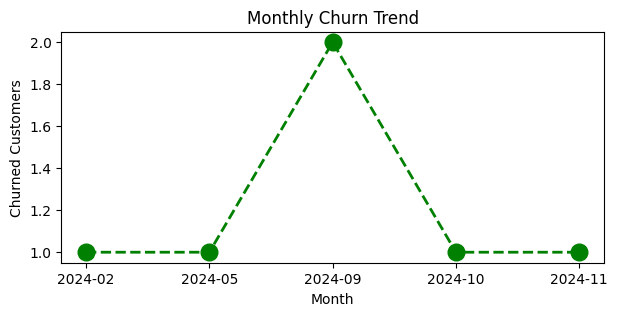

In [ ]:
# 4.1 Monthly Churn Trend (time series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1 ].groupby('cancellation_month').size()

plt.figure(figsize= (7,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values,color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12) 

plt.title("Monthly Churn Trend")
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

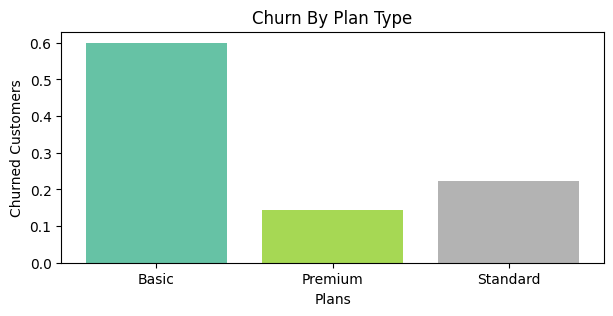

In [ ]:
# 4.2 Churn by Plan type 
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

# this will generate multiple colors based on our churn_plan length
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize= (7,3))
plt.bar(churn_plan.index, churn_paln.values, color= colors)

plt.title("Churn By Plan Type")
plt.xlabel('Plans')
plt.ylabel('Churned Customers')
plt.show()

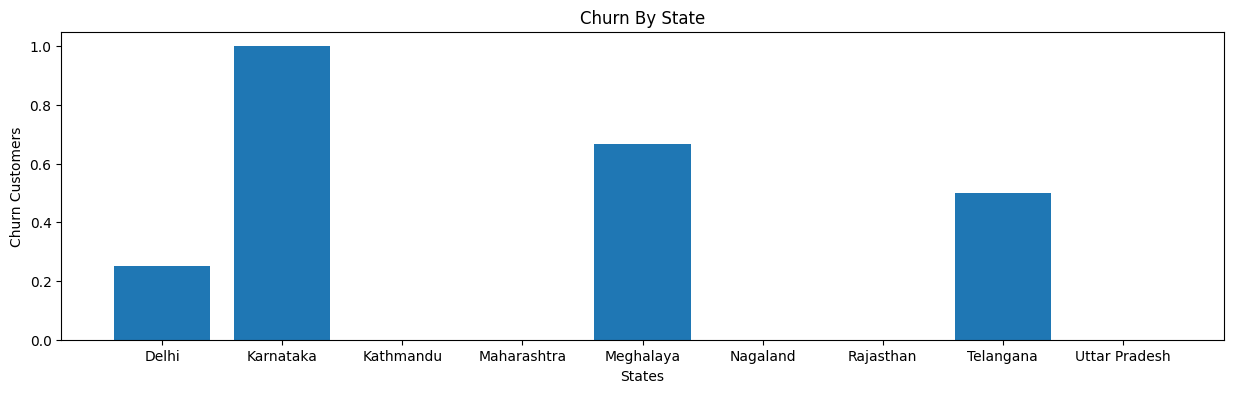

In [ ]:
# 4.3 Churn by state
churn_state = df_visual.groupby('state')['churn_flag'].mean()
# print(churn_state)

plt.figure(figsize=(15,4))

plt.bar(churn_state.index, churn_state.values)
# plt.tight_layout()
plt.title('Churn By State')
plt.xlabel('States')
plt.ylabel('Churn Customers')
plt.show()

In [ ]:
# Visualisation in seaborn 

In [ ]:
# encoding - convert str to numeric so we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [ ]:
df_visual[[ 'plan_type','contract_type','churn_score','churn_flag','escalations','churn_risk']].head()


,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,0,low
1,Premium,Annual,91,1,1,high
2,Basic,Monthly,34,0,0,low
3,Premium,Annual,8,0,0,low
4,Standard,Monthly,88,1,1,high


In [ ]:
df_encode.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# incorrect methord of encoding - as numbers are not assigned based on priority
df_encode = df_visual[[ 'plan_type','contract_type','churn_score','churn_flag','escalations','churn_risk']]

categorical_cols= ['plan_type','contract_type','churn_risk']
# convert all string to numerics
for col in categorical_cols:
    df_encode[col] = df_encode[col].astype('category').cat.codes

<Axes: >

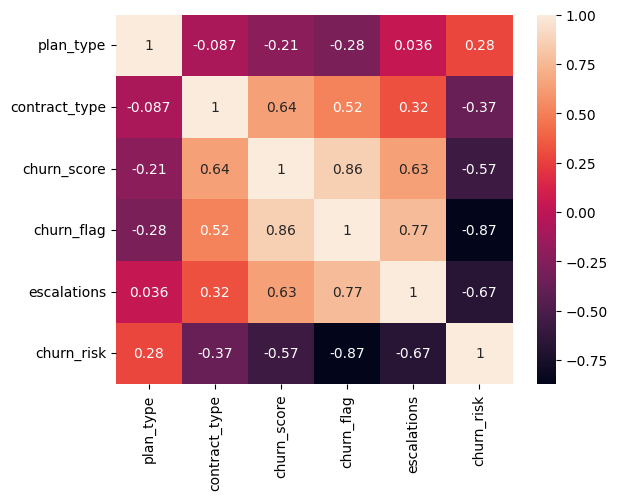

In [ ]:
# Heatmap(correlation matrix) - requires numeric fields
sns.heatmap(df_encode.corr(),annot = True)

In [ ]:
df_visual['churn_risk'].unique()

array(['low', 'high', 'med'], dtype=object)

In [ ]:
# Correct methord of encoding - as numbers are not assigned based on priority
df_encode = df_visual[[ 'plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]

# key value pair
order_mappings = {'plan_type' : ['Basic','Standard','Premium'],
                  'contract_type' : ['Monthly','Annual'],
                  'churn_risk' : ['low','med','high']
                 }
# convert all string to numerics
# 1.Convert to category type — df_encode[col].astype('category') turns the text column into a pandas "category" column.
# 2.Set the order — pd.Categorical(..., categories=order, ordered=True) tells pandas the exact order you want (e.g., Low < Medium < High).
# 3.Turn labels into numbers — .codes replaces each label with its position number based on that order (Low→0, Medium→1, High→2), and you save it back into df_encode[col].
for col, order in order_mappings.items():
    df_encode[col] = pd.Categorical(df_encode[col].astype('category'), categories = order,ordered = True).codes

In [ ]:
df_encode.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

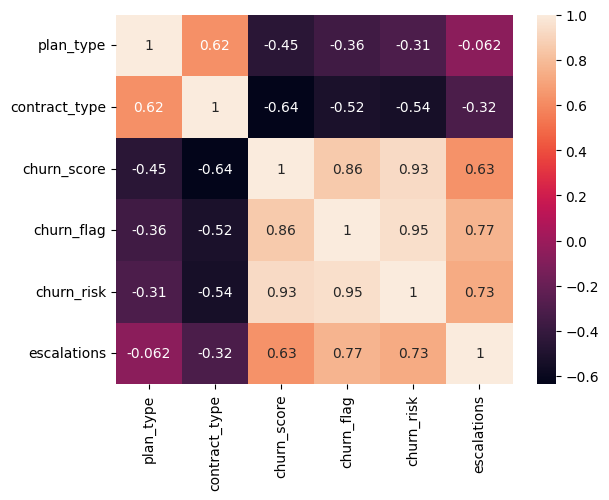

In [ ]:
# Heatmap(correlation matrix) - requires numeric fields
sns.heatmap(df_encode.corr(),annot = True)

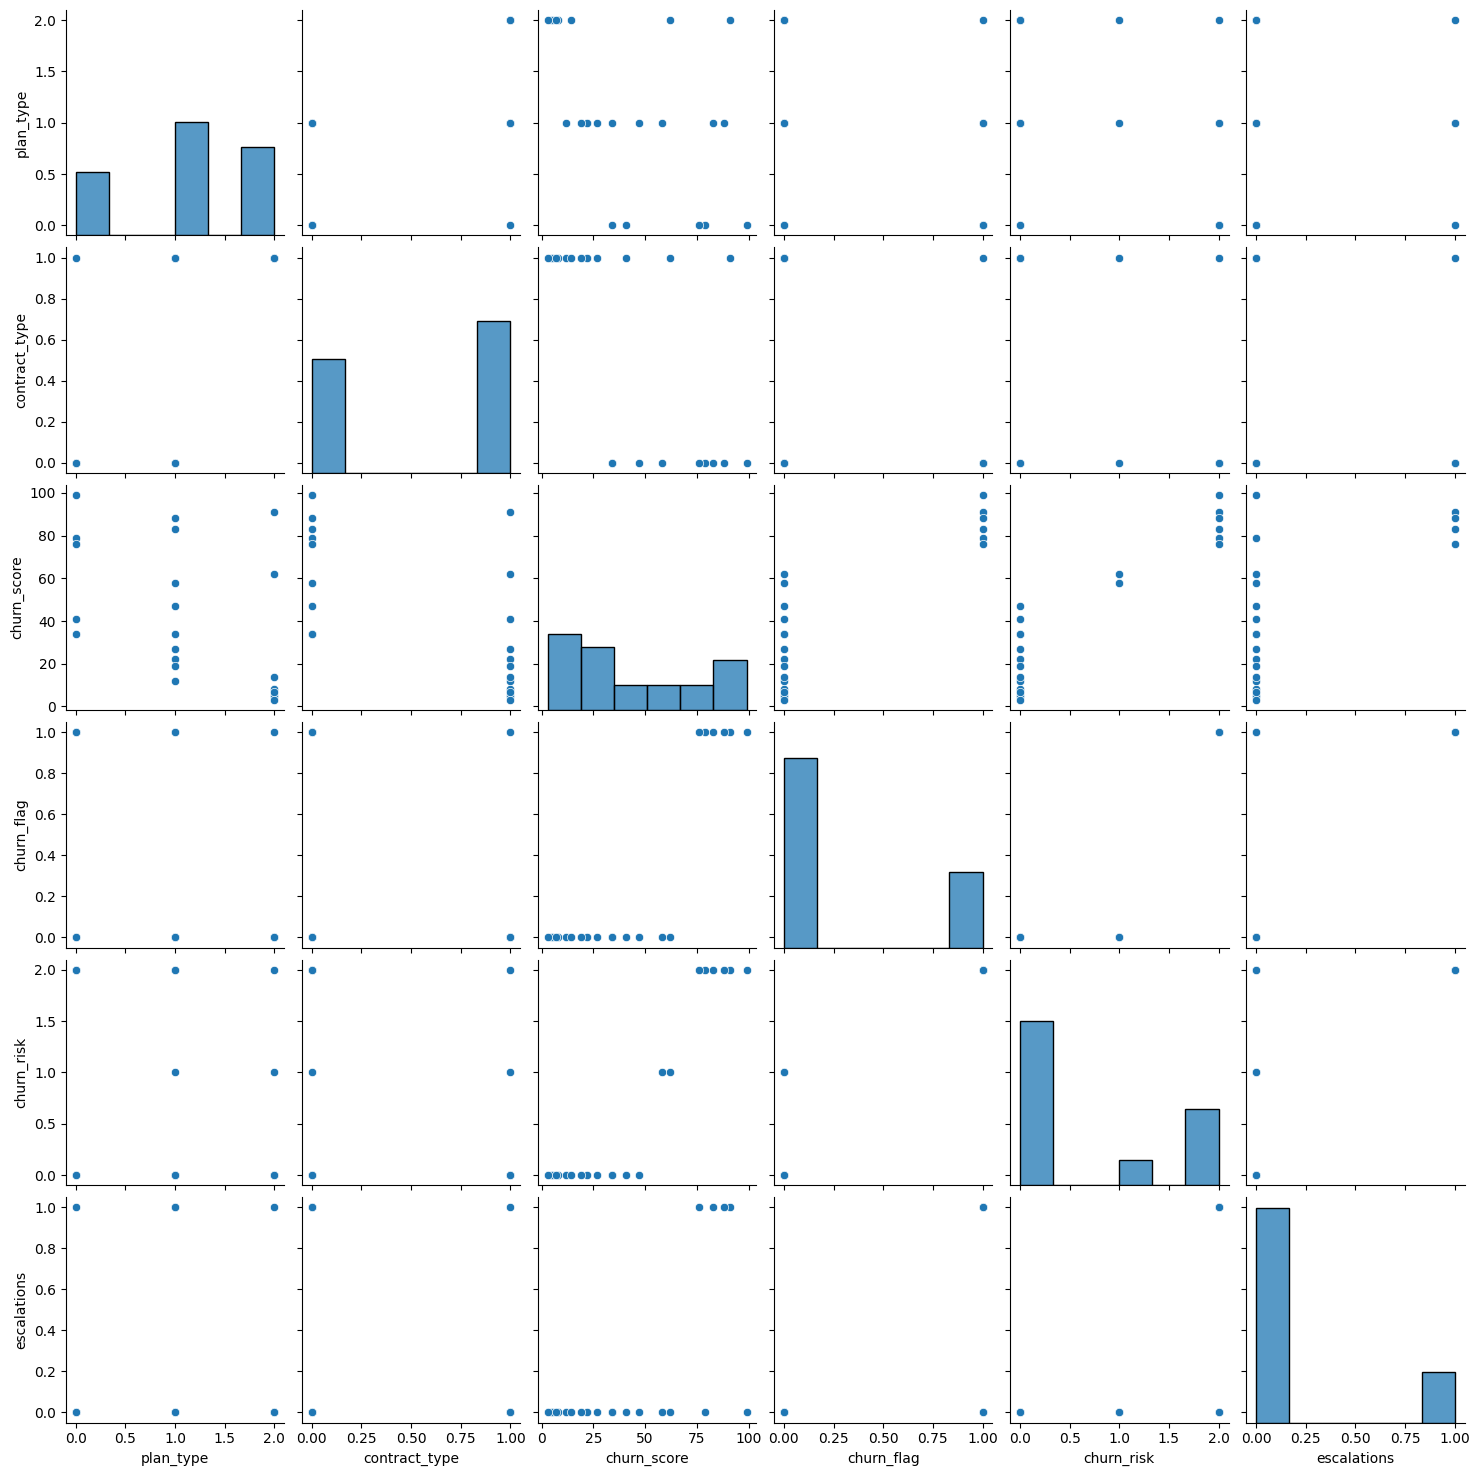

In [ ]:
# pairplot - relationship in a dataset
sns.pairplot(df_encode)

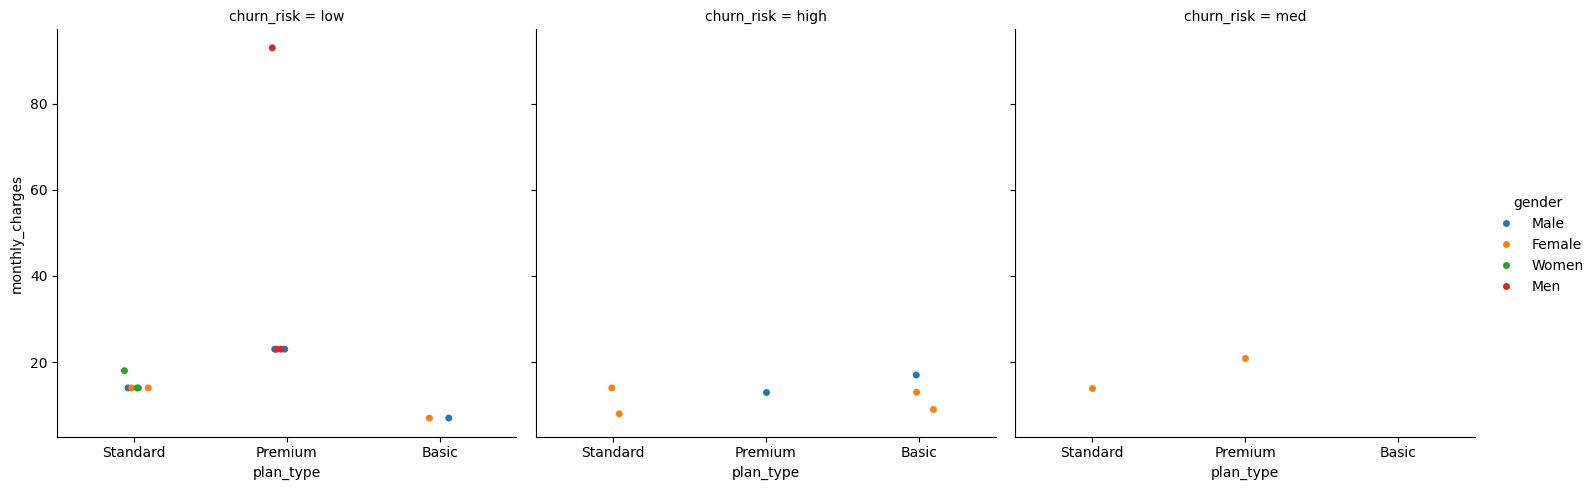

In [ ]:
# catplot/ facegrid plot - multi-dim comparison

sns.catplot(data= df_visual,
            x= 'plan_type',
            y= 'monthly_charges',
            hue= 'gender',
            col= 'churn_risk')


In [ ]:
pd.pivot_table(
    df_visual,
    index= 'plan_type',
    values= ['monthly_charges','customerid','churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [ ]:
#  Working with SQL in python (pandas)
#  all proces are same for sql also

In [ ]:
# create db in sql 
conn = sqlite3.connect('test_database.sqlite')

# table details
conn.execute("CREATE TABLE users ( first_name TEXT , country TEXT, budget INTEGER)")

# commit and save 
conn.commit()

In [ ]:
# insert data 
cursor = conn.cursor()

# write sql query to insert
cursor.execute(
    """
        INSERT INTO users VALUES 
            ('Dev','India',5000),
            ('Rishab','Usa',10000),
            ('vishakha','India',1200)
            
    """
)

# commit and save 
conn.commit()
print("insertion complete")

insertion complete


In [ ]:
# check inserted data in table
conn = sqlite3.connect('test_database.sqlite')

#  first way of reading 
# df_result = pd.read_sql(""" SELECT * FROM users""", conn)

# second way of reading 
query = """ SELECT * FROM users"""

df_result = pd.read_sql(query, conn)
df_result.head()



,first_name,country,budget
0,Dev,india,5000
1,Rishab,usa,10000
2,vishakha,india,1200
3,Dev,India,5000
4,Rishab,Usa,10000


In [ ]:
# aggregagte 
query = """
        SELECT country , SUM(budget) as total_budget
        FROM users
        GROUP BY country
    """
df_aggr = pd.read_sql(query,conn)
df_aggr
conn.commit()

In [ ]:
# always close the conn with db once the task is over
conn.close()
